# One-Class SVM — An Illustrated Tour

> Find the **smallest region** in a kernel feature space that contains most of the training data. Anything outside is an outlier.

---

**What we cover:**
- The core idea — separate data from the origin in feature space
- The role of $\nu$ (upper bound on outliers, lower bound on support vectors)
- The role of $\gamma$ — bandwidth of the RBF kernel
- Score surfaces, decision boundary, support vectors
- Failure mode — wrong kernel scale

## The picture — wrap the normal class in a tight boundary; outside = anomaly

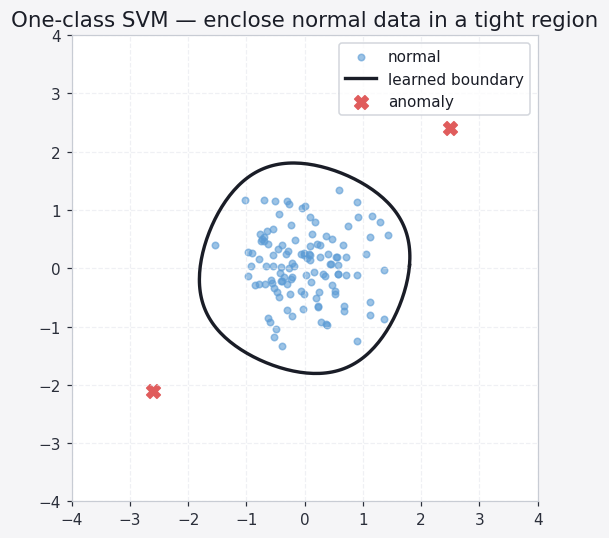

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
inliers = rng.randn(120, 2)*0.6 + np.array([0,0])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(inliers[:,0], inliers[:,1], s=18, color=P[0], alpha=0.6, label='normal')
th = np.linspace(0, 2*np.pi, 200)
ax.plot(1.8*np.cos(th)+0.05*np.sin(3*th), 1.8*np.sin(th)+0.05*np.cos(3*th),
        color='#1a1d27', lw=2.2, label='learned boundary')
ax.scatter([2.5, -2.6], [2.4, -2.1], s=80, color=P[1], marker='X', label='anomaly')
ax.set_aspect('equal'); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_title('One-class SVM — enclose normal data in a tight region')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs, make_moons

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

rng = np.random.default_rng(7)
X_in, _ = make_blobs(n_samples=200, centers=[(0,0)], cluster_std=0.8, random_state=0)
X_out = rng.uniform(-4, 4, size=(20, 2))
X = np.vstack([X_in, X_out])
xx, yy = np.meshgrid(np.linspace(-5,5,250), np.linspace(-5,5,250))
grid = np.c_[xx.ravel(), yy.ravel()]
print('Data:', X.shape)

Data: (220, 2)


---
## The Core Idea — A Tight Boundary Around the Normal Data

One-Class SVM solves

$$\min_{w,\rho,\xi} \; \tfrac{1}{2}\|w\|^2 + \tfrac{1}{\nu m}\sum_i \xi_i - \rho
\quad \text{s.t.}\quad w \cdot \phi(x_i) \geq \rho - \xi_i,\; \xi_i \geq 0.$$

In feature space $\phi(\cdot)$, it finds a hyperplane that **separates the data from the origin** with maximum margin $\rho/\|w\|$.

- $\nu \in (0, 1]$ — fraction of training points allowed to lie outside (also a lower bound on support-vector fraction).
- $\gamma$ — RBF bandwidth: small $\gamma$ → smooth, broad boundary; large $\gamma$ → tight wrap that overfits.

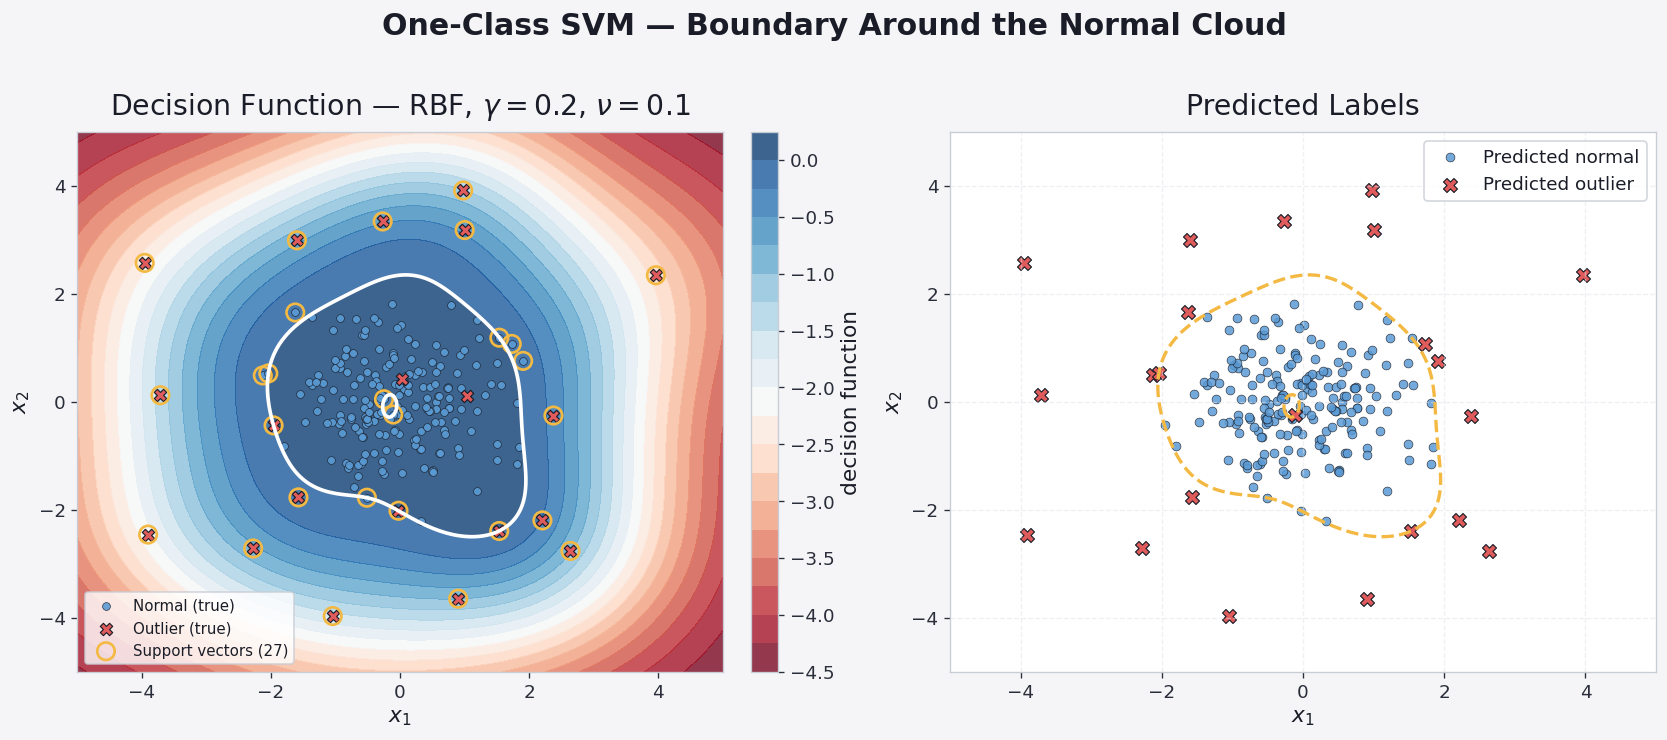

In [3]:
ocsvm = OneClassSVM(kernel='rbf', gamma=0.20, nu=0.10).fit(X)
score = ocsvm.decision_function(grid).reshape(xx.shape)
preds = ocsvm.predict(X)
sv = ocsvm.support_vectors_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
cf = ax.contourf(xx, yy, score, levels=18, cmap='RdBu', alpha=0.80)
ax.contour(xx, yy, score, levels=[0], colors='#ffffff', linewidths=2.2)
ax.scatter(X_in[:,0], X_in[:,1], c=C0, s=22, edgecolors='#1a1d27', lw=0.4, alpha=0.9, label='Normal (true)')
ax.scatter(X_out[:,0], X_out[:,1], c=C1, s=55, marker='X', edgecolors='#1a1d27', lw=0.7, label='Outlier (true)')
ax.scatter(sv[:,0], sv[:,1], s=110, facecolors='none', edgecolors=CB, lw=1.6, label=f'Support vectors ({len(sv)})')
ax.set_title(r'Decision Function — RBF, $\gamma=0.2$, $\nu=0.1$', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(loc='lower left', fontsize=9); ax.grid(False)
plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label='decision function')

ax = axes[1]
ax.scatter(X[preds==1,0],  X[preds==1,1], c=C0, s=28, edgecolors='#1a1d27', lw=0.4, alpha=0.85, label='Predicted normal')
ax.scatter(X[preds==-1,0], X[preds==-1,1], c=C1, s=70, marker='X', edgecolors='#1a1d27', lw=0.7, label='Predicted outlier')
ax.contour(xx, yy, score, levels=[0], colors=CB, linewidths=2, linestyles='--')
ax.set_title('Predicted Labels', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(loc='upper right'); ax.grid(True)
fig.suptitle('One-Class SVM — Boundary Around the Normal Cloud', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## How $\gamma$ and $\nu$ Reshape the Boundary

Sweep both knobs simultaneously to see the behaviour.
- **Top row** ($\gamma$ small → large): boundary tightens around individual points as $\gamma$ grows.
- **Each column** holds $\gamma$ fixed and varies $\nu$ — larger $\nu$ allows more training points to fall outside, so the boundary recedes.

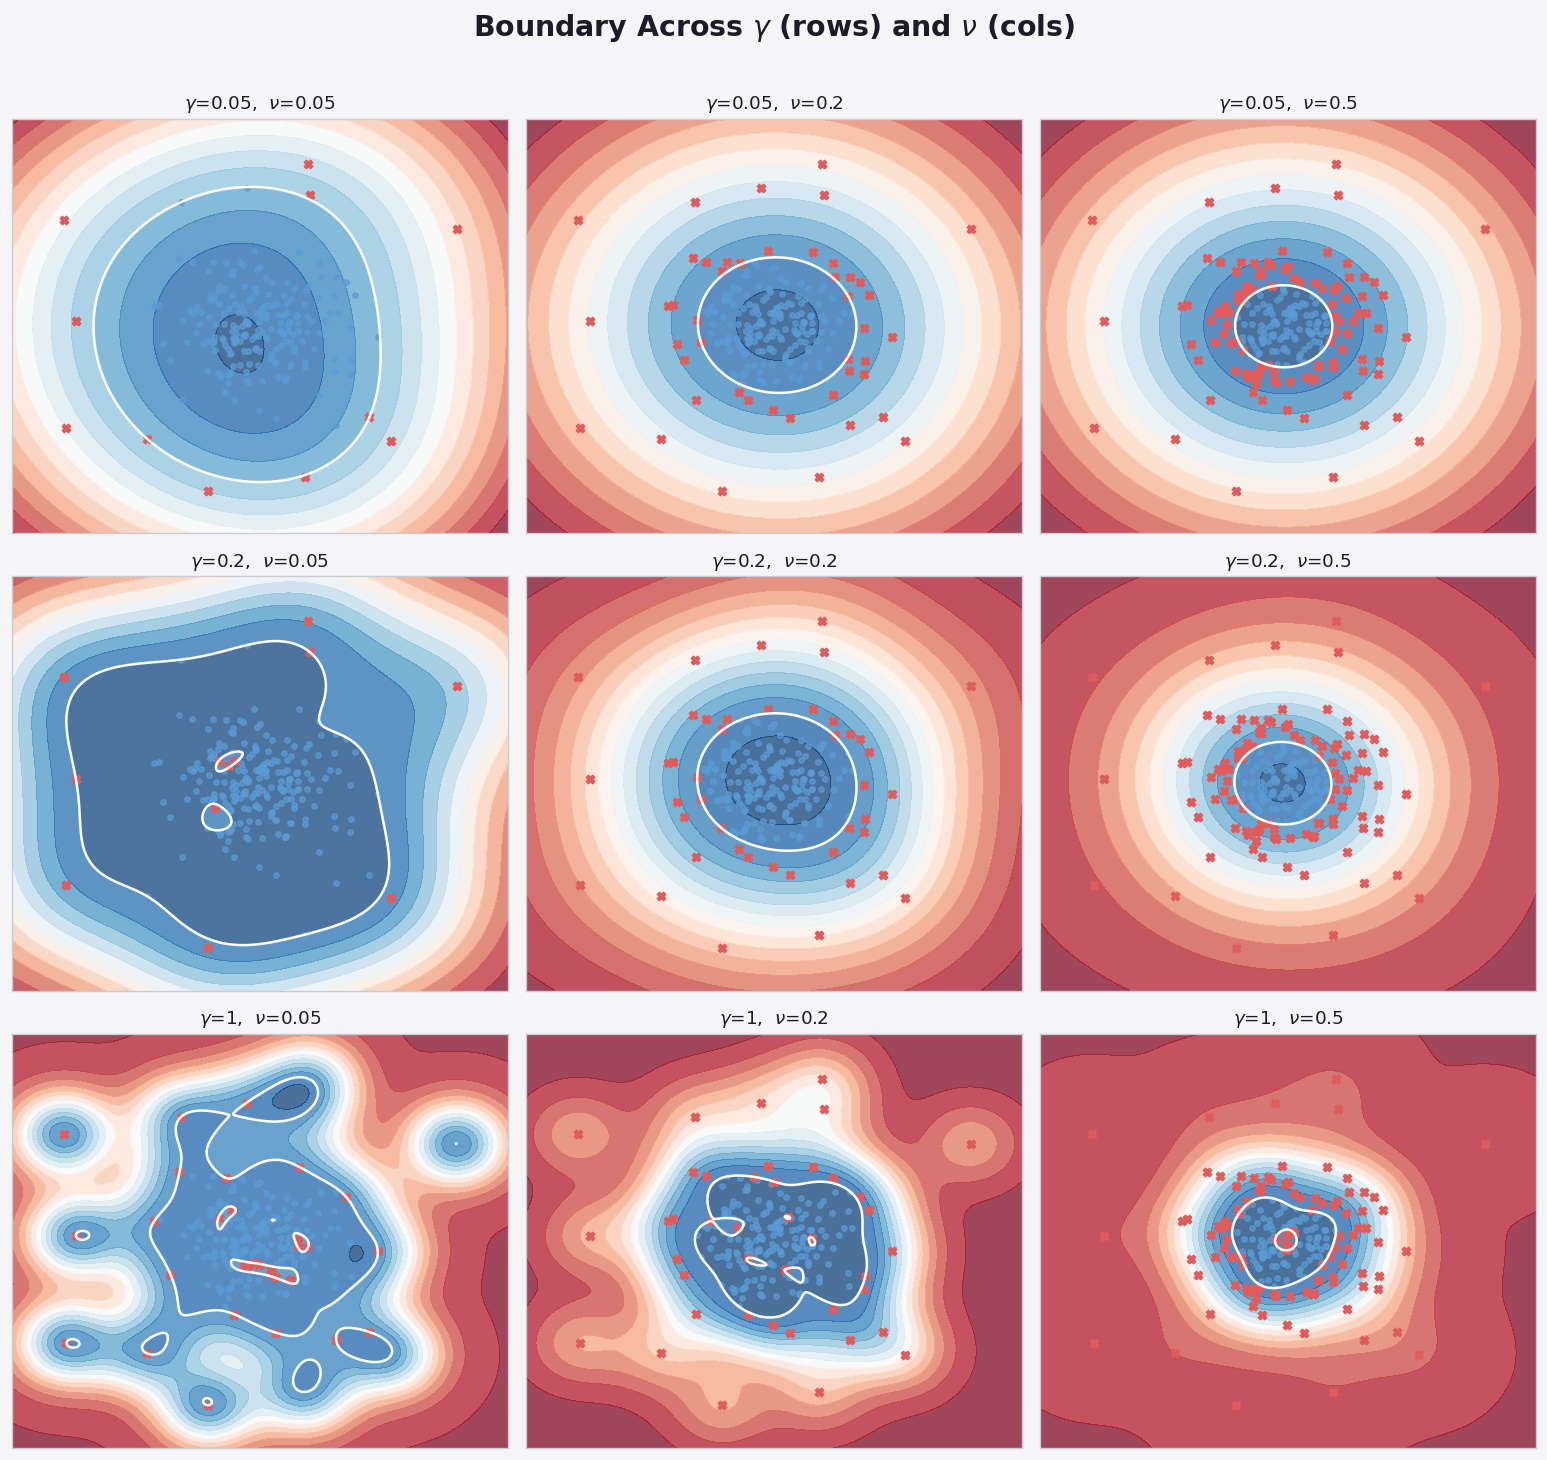

In [4]:
gammas = [0.05, 0.20, 1.0]
nus    = [0.05, 0.20, 0.50]

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for r, g in enumerate(gammas):
    for c, nu in enumerate(nus):
        m = OneClassSVM(kernel='rbf', gamma=g, nu=nu).fit(X)
        s = m.decision_function(grid).reshape(xx.shape)
        p = m.predict(X)
        ax = axes[r, c]
        ax.contourf(xx, yy, s, levels=14, cmap='RdBu', alpha=0.75)
        ax.contour(xx, yy, s, levels=[0], colors='#ffffff', linewidths=1.5)
        ax.scatter(X[p==1,0],  X[p==1,1], c=C0, s=10, alpha=0.7)
        ax.scatter(X[p==-1,0], X[p==-1,1], c=C1, s=24, marker='X')
        ax.set_title(fr'$\gamma$={g:g},  $\nu$={nu:g}', fontsize=11, pad=6)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(r'Boundary Across $\gamma$ (rows) and $\nu$ (cols)', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Failure Mode — Non-Convex Normal Data

One-Class SVM with a single RBF tries to wrap the data in a single connected region. When the normal class is itself a **manifold** (curve), the tightest wrap leaks across the gap. LOF or Isolation Forest are better in that regime.

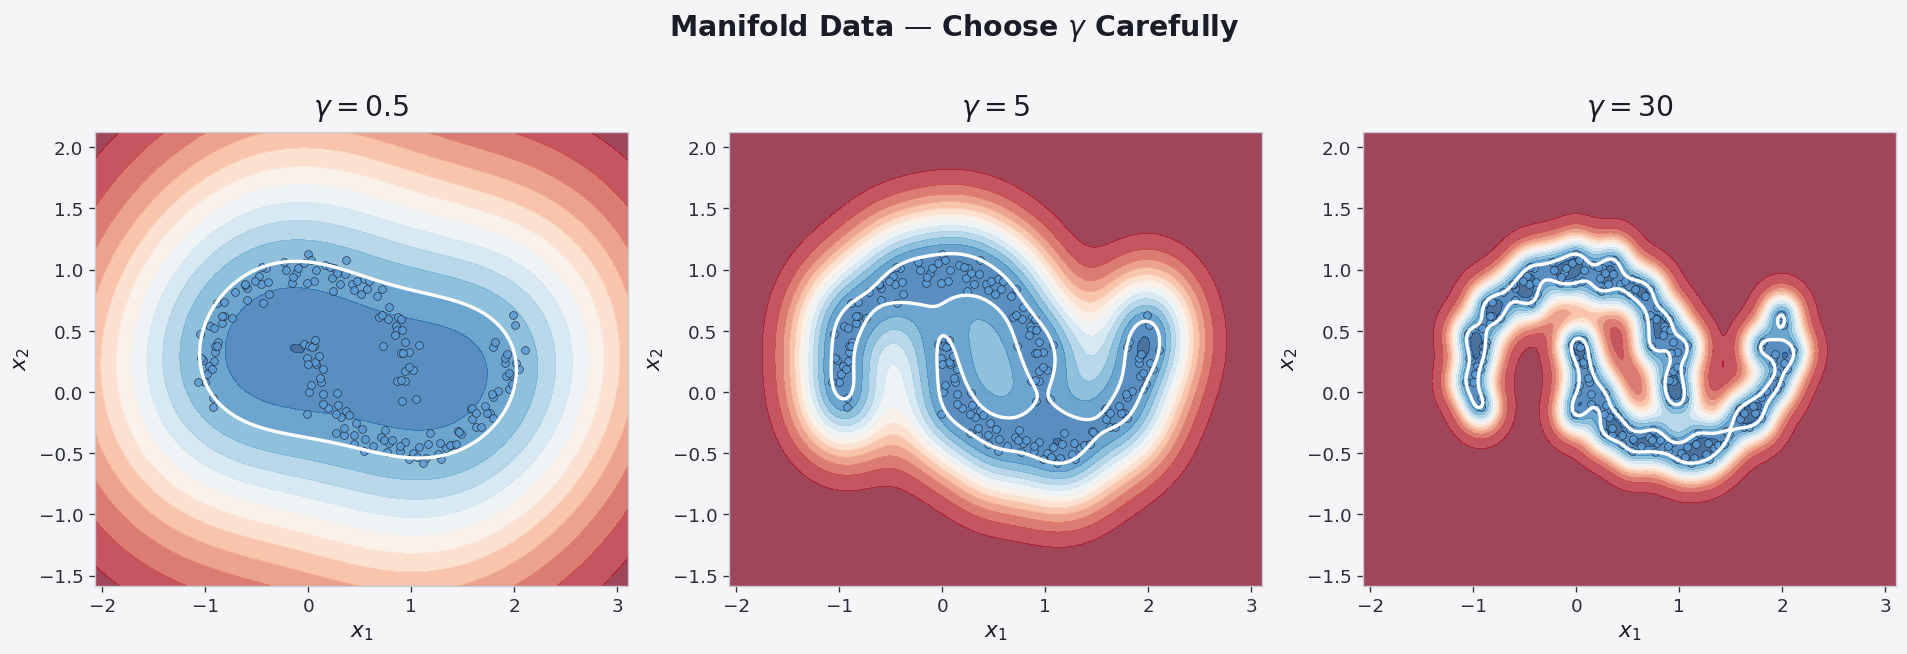

In [5]:
Xm, _ = make_moons(n_samples=180, noise=0.07, random_state=0)
xx2, yy2 = np.meshgrid(np.linspace(Xm[:,0].min()-1.0, Xm[:,0].max()+1.0, 250),
                       np.linspace(Xm[:,1].min()-1.0, Xm[:,1].max()+1.0, 250))
g2 = np.c_[xx2.ravel(), yy2.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, gam in zip(axes, [0.5, 5.0, 30.0]):
    m = OneClassSVM(kernel='rbf', gamma=gam, nu=0.10).fit(Xm)
    s = m.decision_function(g2).reshape(xx2.shape)
    ax.contourf(xx2, yy2, s, levels=14, cmap='RdBu', alpha=0.75)
    ax.contour(xx2, yy2, s, levels=[0], colors='#ffffff', linewidths=2)
    ax.scatter(Xm[:,0], Xm[:,1], c=C0, s=22, edgecolors='#1a1d27', lw=0.4, alpha=0.85)
    ax.set_title(fr'$\gamma={gam:g}$', pad=10)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(False)
fig.suptitle(r'Manifold Data — Choose $\gamma$ Carefully', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use One-Class SVM — and when not to

| Situation | OCSVM | Isolation Forest | LOF |
|---|---|---|---|
| Smooth global boundary in feature space | ✅ | partial | ❌ |
| Many irrelevant / noisy features | ❌ kernel suffers | ✅ | partial |
| Variable-density normal class | ❌ single $\gamma$ | ✅ | ✅ |
| Need a probabilistic score | ❌ | ✅ depth-derived | ✅ |

> Use OCSVM when the **normal class is a single connected blob** and you can scale your features.


---
## 🎯 Try this

1. **$\nu$ as upper bound.** Set $\nu=0.1$ and verify on a clean training set that *at most* 10% of points are flagged outliers — this is OCSVM's nice theoretical guarantee.
2. **Kernel matters.** Replace RBF with `kernel='linear'`. The boundary collapses to a half-space; useful only when your data is genuinely linearly separable from the origin.
3. **Robustness to scale.** Multiply one feature by 100 and observe the boundary distort — then standardise and retry. OCSVM is **not** scale-invariant.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Objective | Separate $\phi(x)$ from origin with margin $\rho$ | Density-level set in feature space |
| $\nu$ | Upper bound on outlier fraction, lower bound on SV fraction | Direct knob on tolerance |
| $\gamma$ | RBF bandwidth | Small → smooth; large → overfits per point |
| Strength | Smooth boundaries, principled kernel framework | Great when normal data is roughly unimodal |
| Weakness | Single connected boundary; $O(m^2)$ to fit | Bad on multi-modal / manifold normal data |

**Bottom line:** One-Class SVM is *boundary-based* anomaly detection. It's beautiful when the normal class is a single blob in some kernel space, but you must tune $\gamma$ and $\nu$ together; a wrong $\gamma$ can hide all the structure.